In [32]:
from typing import Final
import numpy as np
import pandas as pd

# DATA AND SANITY CHECKS

In [ ]:
DATA_FILENAME: Final[str] = "FCM_Dev Trader_Case.xlsx"

In [136]:
# TODO(sparsh): Not provided, but could look up actual financing rates
#     based on e.g. 3M TBill + assumed spread.
FINANCING_RATE: Final[pd.Series | float] = 0.0

In [72]:
def get_universe() -> pd.DataFrame:
    """Get coverage universe and some static data."""
    universe = pd.read_excel(
        DATA_FILENAME,
        sheet_name="Coverage Universe",
        usecols="B:M",
        index_col=0,
        skiprows=1,
    )
    universe["IPO Date"] = pd.to_datetime(
        universe["IPO Date"]
        .replace("#N/A Invalid Security", pd.NaT)
    )
    return universe


universe = get_universe()
universe.head()

,BBG Ticker to Fetch Info,BBG or RT,Analyst,Ticker_Original,Cusip,SEDOL,Ticker and Exchange Code,Exchange Code,Company Long Name,IPO Date,Most Recent Trading Day
Fernbridge Ticker,,,,,,,,,,,
4324.TYS,4324 JP,RT,Analyst2,NaN,NaN,6416281,4324 JP,JP,Dentsu Group Inc,NaT,2/27/2025
6758.TYS,6758 JP,RT,Analyst2,NaN,NaN,6821506,6758 JP,JP,Sony Group Corp,NaT,2/27/2025
7974.TYS,7974 JP,RT,Analyst2,NaN,NaN,6639550,7974 JP,JP,Nintendo Co Ltd,NaT,2/27/2025
ABB,ABBN SW,BBG,Analyst3,NaN,NaN,7108899,ABBN SW,SW,ABB Ltd,NaT,2/27/2025
ABNB,ABNB,BBG,Analyst2,NaN,009066101,BMGYYH4,ABNB US,US,Airbnb Inc,2020-12-10,2/27/2025


In [73]:
sorted(universe["IPO Date"].astype(str).unique())

['1915-11-11',
 '1943-07-06',
 '1948-09-15',
 '1957-01-10',
 '1957-11-12',
 '1960-09-16',
 '1961-10-01',
 '1965-04-21',
 '1967-10-01',
 '1968-04-30',
 '1968-08-26',
 '1969-03-12',
 '1969-03-24',
 '1970-02-02',
 '1971-03-01',
 '1972-06-01',
 '1972-10-01',
 '1980-01-01',
 '1980-10-31',
 '1980-12-01',
 '1981-03-01',
 '1981-09-01',
 '1983-06-01',
 '1983-08-18',
 '1984-05-01',
 '1984-06-01',
 '1985-06-01',
 '1985-11-01',
 '1985-12-05',
 '1986-03-12',
 '1986-03-13',
 '1986-08-01',
 '1986-09-25',
 '1987-06-01',
 '1987-07-01',
 '1988-06-15',
 '1989-10-03',
 '1989-12-13',
 '1989-12-14',
 '1990-02-16',
 '1990-07-01',
 '1991-03-01',
 '1991-09-01',
 '1991-12-17',
 '1992-02-25',
 '1992-06-26',
 '1993-03-11',
 '1993-06-07',
 '1993-10-05',
 '1994-03-16',
 '1994-05-25',
 '1994-06-09',
 '1995-03-14',
 '1995-06-21',
 '1995-11-16',
 '1995-12-07',
 '1996-06-19',
 '1996-06-27',
 '1996-07-18',
 '1996-08-01',
 '1996-12-11',
 '1997-02-04',
 '1997-03-06',
 '1997-04-14',
 '1997-05-14',
 '1997-10-07',
 '1998-01-

In [16]:
def get_mapping_from_bbg_to_fernbridge_ticker() -> pd.Series:
    return pd.Series(
        {
            bbg_ticker: fernbridge_ticker
            for fernbridge_ticker, bbg_ticker
            in universe["BBG Ticker to Fetch Info"].items()
        }
    )


mapping_from_bbg_to_fernbridge_ticker = get_mapping_from_bbg_to_fernbridge_ticker()
mapping_from_bbg_to_fernbridge_ticker

4324 JP    4324.TYS
6758 JP    6758.TYS
7974 JP    7974.TYS
ABBN SW         ABB
ABNB           ABNB
             ...   
YUM             YUM
ZEN             ZEN
ZI               ZI
ZM               ZM
ZS               ZS
Length: 297, dtype: object

In [108]:
def get_excess_returns_for_index(
    # TODO(sparsh): Not provided, but could look up actual financing rates
    #     based on e.g. 3M TBill + assumed spread.
    financing_rate: pd.Series | float = 0.0,
) -> pd.DataFrame:
    """Get excess returns for indices, provided a financing rate."""
    px = pd.read_excel(
        DATA_FILENAME,
        sheet_name="Raw Market Data",
        usecols="A:D",
        index_col=0,
        skiprows=2,
    )
    px = px.asfreq(freq="D")
    px = px.ffill()
    r = px / px.shift() - 1
    # Get rid of spurious zero returns over weekends.
    # TODO(sparsh): Take into account trading holidays
    #     using e.g. `holidays` or `pandas-market-calendars`.
    r = r.asfreq(freq="B")
    xr = r - financing_rate
    return xr


excess_returns_for_index = get_excess_returns_for_index()
excess_returns_for_index.head()

,SPXT,XNDX,XCMP
Date,,,
2024-01-01,0.000000,0.000000,0.000000
2024-01-02,-0.005629,-0.016666,-0.016300
2024-01-03,-0.007975,-0.010477,-0.011699
2024-01-04,-0.003297,-0.005254,-0.005589
2024-01-05,0.001827,0.001472,0.000953


In [135]:
def get_excess_returns_for_stocks(
    financing_rate: pd.Series | float = FINANCING_RATE,
) -> pd.DataFrame:
    """Get excess returns for stocks, provided a financing rate."""
    r = pd.read_excel(
        DATA_FILENAME,
        sheet_name="Raw Market Data",
        usecols="H,O:KY",
        index_col=0,
        skiprows=2,
    )
    # drop blank first row
    r = r.iloc[1:, :]
    r = r.asfreq(freq="D")
    r = r.fillna(0)
    # Get rid of spurious zero returns over weekends.
    # TODO(sparsh): Take into account trading holidays
    #     using e.g. `holidays` or `pandas-market-calendars`.
    r = r.asfreq(freq="B")
    xr = r - financing_rate
    # rename
    unmapped_tickers = xr.columns.difference(
        mapping_from_bbg_to_fernbridge_ticker.index
    )
    if not unmapped_tickers.empty:
        raise RuntimeError(f"Unmapped tickers! {unmapped_tickers}")
    xr = xr.rename(columns=mapping_from_bbg_to_fernbridge_ticker)
    xr = xr.loc[:, universe.index]
    # null out pre-IPO returns
    for ticker, ipo_date in universe["IPO Date"].items():
        ipo_date = ipo_date if pd.notna(ipo_date) else None
        xr[ticker] = xr.loc[ipo_date:, ticker]
    return xr


excess_returns_for_stocks = get_excess_returns_for_stocks()
excess_returns_for_stocks.head()

Fernbridge Ticker,4324.TYS,6758.TYS,7974.TYS,ABB,ABNB,AC.PAR,ACN,ADBE,ADI,ADSK,...,WORK,WPP.LSE,WU,WYNN,YELP,YUM,ZEN,ZI,ZM,ZS
Start,,,,,,,,,,,,,,,,,,,,,
2024-01-01,0.00000,0.000000,0.000000,0.000000,-0.012193,0.001156,-0.011370,-0.027707,-0.025081,-0.038443,...,0.0,-0.009562,0.017617,0.038305,-0.020490,-0.012475,0.0,-0.038940,-0.038381,-0.041479
2024-01-02,0.00000,0.000000,0.000000,-0.031635,-0.007882,-0.007794,-0.025943,-0.014274,-0.023866,-0.029600,...,0.0,-0.021990,-0.024732,-0.006025,-0.007764,0.000543,0.0,-0.051210,-0.028633,-0.010030
2024-01-03,0.02377,-0.023490,-0.024868,0.009690,0.002249,0.004364,-0.002456,-0.008290,-0.015294,0.007615,...,0.0,0.017549,-0.006762,0.001914,0.002825,-0.003176,0.0,-0.002372,-0.004020,0.000428
2024-01-04,0.00432,0.005727,0.006550,-0.013436,0.016901,-0.007242,-0.001394,-0.004321,0.002580,0.002621,...,0.0,0.037726,0.017872,0.015285,-0.025358,-0.002720,0.0,0.014269,0.000897,-0.002472
2024-01-05,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [110]:
# there should be 1 always-null pre-ipo stock
excess_returns_for_stocks.isna().sum(axis="columns")

Start
2024-01-01    1
2024-01-02    1
2024-01-03    1
2024-01-04    1
2024-01-05    1
             ..
2024-12-24    1
2024-12-25    1
2024-12-26    1
2024-12-27    1
2024-12-30    1
Freq: B, Length: 261, dtype: int64

In [111]:
def get_compounded_returns(
    excess_returns: pd.Series,
    financing_rate: pd.Series | float = FINANCING_RATE,
) -> pd.Series:
    total_returns = excess_returns + financing_rate
    compounded_returns = (
        (1 + total_returns.fillna(0))
        .cumprod()
        .iloc[-1, :]
        - 1
    )
    return compounded_returns

In [112]:
compounded_returns_for_index = get_compounded_returns(
    excess_returns=excess_returns_for_index,
)
compounded_returns_for_index

SPXT    0.250197
XNDX    0.258840
XCMP    0.295731
Name: 2024-12-31 00:00:00, dtype: float64

In [113]:
compounded_returns_for_stocks = get_compounded_returns(
    excess_returns=excess_returns_for_stocks,
)
compounded_returns_for_stocks

Fernbridge Ticker
4324.TYS    0.182637
6758.TYS    0.311032
7974.TYS    0.484832
ABB         0.173452
ABNB       -0.167373
              ...   
YUM         0.081056
ZEN         0.000000
ZI         -0.436857
ZM          0.077409
ZS         -0.304770
Name: 2024-12-30 00:00:00, Length: 297, dtype: float64

In [114]:
compounded_returns_for_stocks_binned = pd.qcut(
    compounded_returns_for_stocks,
    q=10,
    labels=range(1, 11),
)
compounded_returns_for_stocks_binned

Fernbridge Ticker
4324.TYS     7
6758.TYS     9
7974.TYS    10
ABB          7
ABNB         2
            ..
YUM          6
ZEN          4
ZI           1
ZM           6
ZS           1
Name: 2024-12-30 00:00:00, Length: 297, dtype: category
Categories (10, int64): [1 < 2 < 3 < 4 ... 7 < 8 < 9 < 10]

In [25]:
def _get_pflio_dta() -> pd.DataFrame:
    """Pull info from "Portfolio" tab."""
    dta = pd.read_excel(
        DATA_FILENAME,
        sheet_name="Portfolio",
        usecols="B:K",
        index_col=[0, 2, 3],
        parse_dates=[3],
        skiprows=2,
    )
    dta = dta.sort_index()
    return dta


_pflio_dta = _get_pflio_dta()
_pflio_dta.head()

Label  \
Level (Fund / Analyst / Stock) Adjusted Label Date                   
Analyst                        Analyst1       2024-01-01  Analyst1   
                                              2024-01-02  Analyst1   
                                              2024-01-03  Analyst1   
                                              2024-01-04  Analyst1   
                                              2024-01-05  Analyst1   

                                                          Combined_G/L_Daily  \
Level (Fund / Analyst / Stock) Adjusted Label Date                             
Analyst                        Analyst1       2024-01-01        0.000000e+00   
                                              2024-01-02       -5.015726e+06   
                                              2024-01-03       -1.717630e+06   
                                              2024-01-04       -4.679475e+05   
                                              2024-01-05       -6.096062e+05   

                                                          Combined_Exposure_EOD  \
Level (Fund / Analyst / Stock) Adjusted Label Date                                
Analyst                        Analyst1       2024-01-01           1.787261e+08   
                                              2024-01-02           1.787261e+08   
                                              2024-01-03           1.720464e+08   
                                              2024-01-04           1.698800e+08   
                                              2024-01-05           1.682185e+08   

                                                          Return_Daily  \
Level (Fund / Analyst / Stock) Adjusted Label Date                       
Analyst                        Analyst1       2024-01-01      0.000000   
                                              2024-01-02     -0.028064   
                                              2024-01-03     -0.009984   
                                              2024-01-04     -0.002755   
                                              2024-01-05     -0.003624   

                                                          Raw Stock Return_Daily  \
Level (Fund / Analyst / Stock) Adjusted Label Date                                 
Analyst                        Analyst1       2024-01-01                     NaN   
                                              2024-01-02                     NaN   
                                              2024-01-03                     NaN   
                                              2024-01-04                     NaN   
                                              2024-01-05                     NaN   

                                                          Index Return_Daily  \
Level (Fund / Analyst / Stock) Adjusted Label Date                             
Analyst                        Analyst1       2024-01-01            0.000000   
                                              2024-01-02           -0.005629   
                                              2024-01-03           -0.007974   
                                              2024-01-04           -0.003298   
                                              2024-01-05            0.001828   

                                                          Contribution_Daily  
Level (Fund / Analyst / Stock) Adjusted Label Date                            
Analyst                        Analyst1       2024-01-01            0.000000  
                                              2024-01-02           -0.005828  
                                              2024-01-03           -0.002000  
                                              2024-01-04           -0.000539  
                                              2024-01-05           -0.000717

In [148]:
sorted(_pflio_dta.index.levels[1].unique())

['ADSK',
 'AMZN',
 'APP',
 'ASML',
 'Analyst1',
 'Analyst2',
 'Analyst3',
 'Analyst4',
 'Analyst5',
 'Analyst6',
 'BKNG',
 'CHTR',
 'CMG',
 'CNM',
 'CRM',
 'DASH',
 'DKNG',
 'FB',
 'FIS',
 'Fund Total',
 'GOOGL',
 'INTU',
 'IT',
 'LYFT',
 'LYV',
 'MA',
 'MCD',
 'MSFT',
 'NFLX',
 'PTC',
 'SHW',
 'SPOT',
 'TMUS',
 'TSM',
 'TTEK',
 'UBER',
 'UMG.AMS',
 'V',
 'VMC',
 'VZ',
 'WDAY',
 'WMG',
 'WMS']

In [29]:
def get_fund_nav() -> pd.Series:
    """Get fund-level NAV by day."""
    nav = _pflio_dta.loc[("Fund", "Fund Total"), "Combined_Exposure_EOD"]
    nav = nav.asfreq("D")
    nav = nav.ffill()
    nav = nav.asfreq("B")
    return nav


fund_nav = get_fund_nav()
fund_nav.head()

Date
2024-01-01    8.606660e+08
2024-01-02    8.606742e+08
2024-01-03    8.588705e+08
2024-01-04    8.684963e+08
2024-01-05    8.508014e+08
Freq: B, Name: Combined_Exposure_EOD, dtype: float64

In [87]:
fund_nav.tail()

Date
2024-12-25    1.908363e+09
2024-12-26    1.908383e+09
2024-12-27    1.903913e+09
2024-12-30    1.885261e+09
2024-12-31    1.865472e+09
Freq: B, Name: Combined_Exposure_EOD, dtype: float64

In [83]:
def get_equal_wts() -> pd.DataFrame:
    """
    Get portfolio weights for an equal-weighted portfolio.

    Includes only post-IPO stocks.
    """
    stock_is_post_ipo = excess_returns_for_stocks.notna().astype(int)
    wts = stock_is_post_ipo.divide(
        stock_is_post_ipo.sum(axis="columns"),
        axis="index",
    )
    return wts


equal_wts = get_equal_wts()
equal_wts.head()

Fernbridge Ticker,4324.TYS,6758.TYS,7974.TYS,ABB,ABNB,AC.PAR,ACN,ADBE,ADI,ADSK,...,WORK,WPP.LSE,WU,WYNN,YELP,YUM,ZEN,ZI,ZM,ZS
Start,,,,,,,,,,,,,,,,,,,,,
2024-01-01,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,...,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378
2024-01-02,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,...,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378
2024-01-03,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,...,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378
2024-01-04,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,...,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378
2024-01-05,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,...,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378,0.003378


In [85]:
1/296

0.0033783783783783786

In [90]:
def get_pflio_wts_eod() -> pd.DataFrame:
    """Get portfolio weights by day."""
    dta = _pflio_dta.loc["Stock", :]
    # sign
    true_sign_of_exposure = np.sign(dta["Combined_G/L_Daily"])
    unsigned_exposure = dta["Combined_Exposure_EOD"]
    recorded_sign_of_exposure = np.sign(unsigned_exposure)
    assert not (recorded_sign_of_exposure < 0).any(), "Assumed sign convention is wrong!"
    signed_exposure = true_sign_of_exposure * unsigned_exposure
    assert isinstance(signed_exposure, pd.Series), type(signed_exposure)
    signed_exposure = signed_exposure.unstack(level="Adjusted Label")
    signed_exposure = signed_exposure.asfreq(freq="D")
    signed_exposure = (
        signed_exposure
        .ffill()
        # if we've never held this position, propagate zero
        .fillna(0)
    )
    signed_exposure = signed_exposure.asfreq("B")
    wts = signed_exposure.divide(fund_nav, axis="index")
    unrecognized_tickers = wts.columns.difference(universe.index)
    if not unrecognized_tickers.empty:
        raise RuntimeError(unrecognized_tickers)
    wts = wts.reindex(columns=universe.index).fillna(0)
    return wts


pflio_wts_eod = get_pflio_wts_eod()
pflio_wts_eod.head()

Fernbridge Ticker,4324.TYS,6758.TYS,7974.TYS,ABB,ABNB,AC.PAR,ACN,ADBE,ADI,ADSK,...,WORK,WPP.LSE,WU,WYNN,YELP,YUM,ZEN,ZI,ZM,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
(pflio_wts != 0).mean().mean()

0.08981674248849822

# CASE STUDY

In [118]:
# assumes no rebalancing
compounded_returns_for_stocks.mean()

0.09845291628412804

In [117]:
# assumes daily rebalancing
(
    1
    + (equal_wts * excess_returns_for_stocks).sum(axis="columns")
).cumprod()

Start
2024-01-01    0.986794
2024-01-02    0.967955
2024-01-03    0.967297
2024-01-04    0.968074
2024-01-05    0.968074
                ...   
2024-12-24    1.090495
2024-12-25    1.092047
2024-12-26    1.082930
2024-12-27    1.082930
2024-12-30    1.083005
Freq: B, Length: 261, dtype: float64

In [126]:
# assumes no rebalancing
for q in compounded_returns_for_stocks_binned.unique().sort_values():
    avg_ret = compounded_returns_for_stocks.loc[
        compounded_returns_for_stocks_binned == q
    ].mean()
    print(f"Decile {q}: {avg_ret:.2%}")

Decile 1: -44.95%
Decile 2: -22.47%
Decile 3: -10.96%
Decile 4: -0.79%
Decile 5: 1.66%
Decile 6: 7.42%
Decile 7: 15.12%
Decile 8: 24.14%
Decile 9: 36.02%
Decile 10: 93.62%


In [141]:
pflio_xr = (
    pflio_wts_eod  # .shift()
    * excess_returns_for_stocks
)
pflio_xr.loc[pflio_xr.index[-1]] = pflio_xr.iloc[-1, :].fillna(0)

<Axes: >

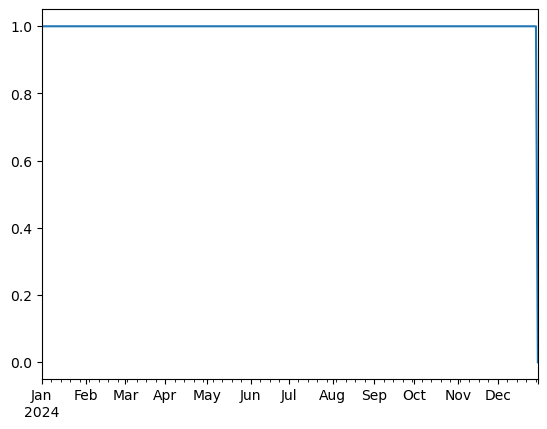

In [142]:
pflio_xr.isna().sum(axis="columns").plot()

In [143]:
pflio_cret = (
    1 + pflio_xr + FINANCING_RATE
).cumprod().iloc[-1, :] - 1
pflio_cret

Fernbridge Ticker
4324.TYS    0.0
6758.TYS    0.0
7974.TYS    0.0
ABB         0.0
ABNB        0.0
           ... 
YUM         0.0
ZEN         0.0
ZI          0.0
ZM          0.0
ZS          0.0
Name: 2024-12-31 00:00:00, Length: 297, dtype: float64

<Axes: xlabel='Fernbridge Ticker'>

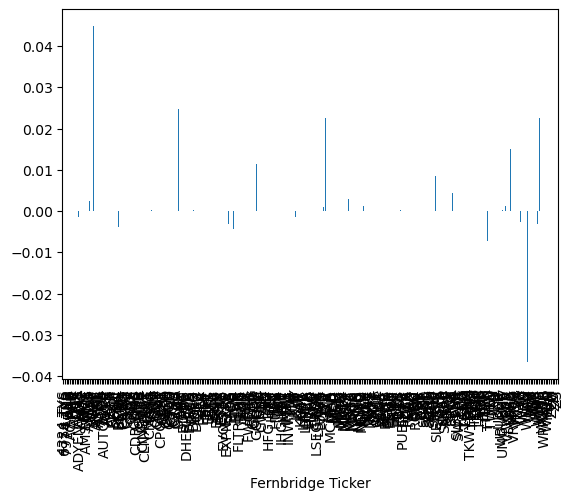

In [144]:
pflio_cret.plot(kind="bar")

In [155]:
pflio_cret = pflio_cret.loc[
    pflio_cret != 0
]
pflio_cret.sort_values().rename("").to_frame() * 1_00_00

,
Fernbridge Ticker,
WDAY,-366.813291
CNM,-330.743833
TTEK,-73.131794
UBER,-46.218194
CHTR,-44.698854
FIS,-43.882415
BKNG,-39.123740
FB,-32.208667
WMG,-31.283167


In [157]:
pflio_cret.sum()

0.06702508053852096

In [128]:
# portfolio
(
    1
    + (
        pflio_wts_eod  # .shift()
        * excess_returns_for_stocks
    ).sum(axis="columns")
).cumprod()

2024-01-01    0.999567
2024-01-02    1.008237
2024-01-03    1.010059
2024-01-04    1.020069
2024-01-05    1.020069
                ...   
2024-12-25    1.057621
2024-12-26    1.061475
2024-12-27    1.061475
2024-12-30    1.063547
2024-12-31    1.063547
Freq: B, Length: 262, dtype: float64